In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score


In [13]:
import nolds

In [3]:
def plot_fs(x):
    n = len(x)
    fft_vals = np.fft.rfft(x,n)
    psd = np.abs(fft_vals)**2
    freqs = np.fft.rfftfreq(n)
    plt.plot(freqs[1:n//10], psd[1:n//10])
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title("Fourier Spectrum")
    plt.show()

In [10]:
def MG_generate_interp(gamma=0.1,beta=0.2,tau=60,theta=1,n=10,x0=0.2,N=1000000,delta=0.01,interval=1):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+0.1
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  return T[::100],X[::100]

In [11]:
T,X = MG_generate_interp()

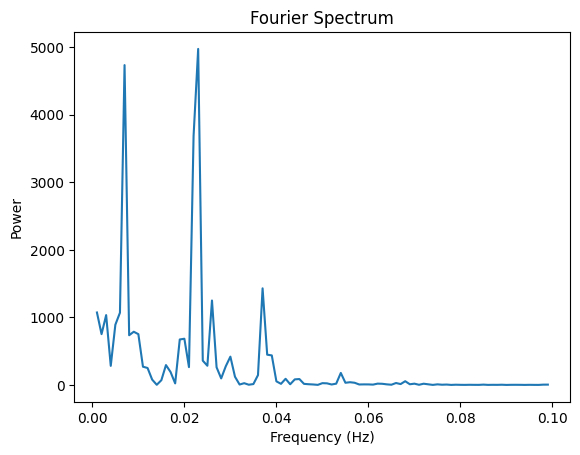

In [32]:
plot_fs(X[10000:11000])

In [38]:
def plot_ami_lag(x, max_lag=100, bins=64):
    # Discretize data into bins
    _, bin_edges = np.histogram(x, bins=bins)
    digitized = np.digitize(x, bin_edges[:-1])
    
    ami = []
    for lag in range(1, max_lag):
        x1 = digitized[:-lag]
        x2 = digitized[lag:]
        mi = mutual_info_score(x1, x2)
        ami.append(mi)

    plt.plot(range(1, max_lag), ami)
    plt.xlabel("Lag")
    plt.ylabel("AMI")
    plt.title("Average Mutual Information")
    plt.show()

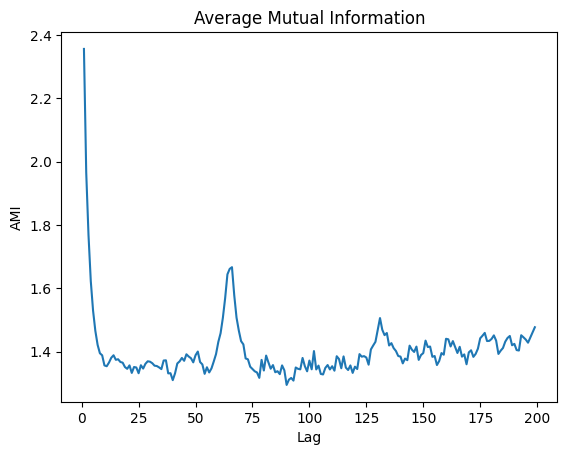

In [42]:
plot_ami_lag(X[10000:11000], max_lag=200, bins=64)

In [44]:
import requests
import pickle
import io

In [45]:
def load_data_from_hf(url: str):
    response = requests.get(url)
    data = pickle.load(io.BytesIO(response.content))
    return data

In [46]:
import pandas as pd

In [47]:
url = "https://huggingface.co/datasets/zyllab/TTMs_on_MG/resolve/main/all_MGdatas.pkl"
data = load_data_from_hf(url)
df = pd.DataFrame(data)

In [48]:
import nolds

In [ ]:
def mf_value(x):
    n = len(x)
    fft_vals = np.fft.rfft(x,n)
    psd = np.abs(fft_vals)**2
    freqs = np.fft.rfftfreq(n)
    mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])
    return mean_freq

def compute_ami_lag(x, max_lag=100, bins=64):
    # Discretize data into bins
    hist, bin_edges = np.histogram(x, bins=bins)
    digitized = np.digitize(x, bin_edges[:-1])
    
    ami = []
    for lag in range(1, max_lag):
        x1 = digitized[:-lag]
        x2 = digitized[lag:]
        mi = mutual_info_score(x1, x2)
        ami.append(mi)

    # Find the first local minimum
    for i in range(1, len(ami) - 1):
        if ami[i] < ami[i-1] and ami[i] < ami[i+1]:
            return i + 1, ami  # +1 because lag starts at 1

    return np.argmin(ami) + 1, ami  # fallback if no local min
def compute_le(x):
    mf = mf_value(x)
    min_tsep = int(round(1/mf))
    lag,_ = compute_ami_lag(x,bins = 100)
    #print(min_tsep,lag)
    le = nolds.lyap_r(x,min_tsep=min_tsep,lag=lag)
    return le

In [60]:
df['x0'][1]

np.float64(0.2)

In [75]:
df_filtered = df[
    (df['x0']==((2+1)/5)) &
    (df['tau']==200)
]
np.array(df_filtered['X'].tolist())[0,8000:9000]

array([1.24545083, 1.24201183, 1.23216151, 1.21660503, 1.19617832,
       1.17188202, 1.14490013, 1.11657912, 1.08835367, 1.06159018,
       1.03733829, 1.0160635 , 0.99751679, 0.98086815, 0.9650597 ,
       0.94916673, 0.93258735, 0.91505435, 0.89655912, 0.87726129,
       0.85741544, 0.8373231 , 0.81730906, 0.7977178 , 0.77892315,
       0.76134458, 0.74546613, 0.731856  , 0.72118491, 0.71423889,
       0.71191834, 0.71521096, 0.72512469, 0.74257167, 0.7682028 ,
       0.80219234, 0.84394576, 0.89168141, 0.94194206, 0.98943838,
       1.02790214, 1.05205042, 1.05948291, 1.05115363, 1.03044777,
       1.00189686, 0.97028727, 0.94028451, 0.91636649, 0.90274779,
       0.90291935, 0.91856038, 0.94824997, 0.98726451, 1.02923395,
       1.06850517, 1.10149436, 1.12670382, 1.14411535, 1.1545743 ,
       1.15937031, 1.15999996, 1.15804479, 1.15510806, 1.15277319,
       1.1525596 , 1.15585579, 1.1638002 , 1.1770576 , 1.19541653,
       1.21717629, 1.23855053, 1.25382934, 1.25708714, 1.24473

In [82]:
les = []
for i in range(200):
    df_filtered = df[
        (df['x0']==((i+1)/5)) &
        (df['tau']==60)
    ]
    x = np.array(df_filtered['X'].tolist())[0,8000:8500]
    les.append(compute_le(x))

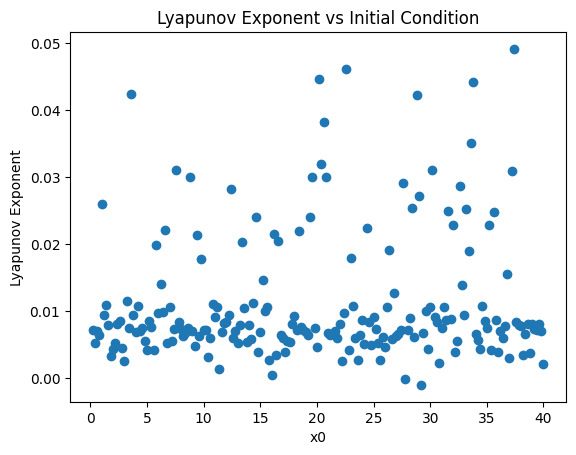

In [83]:
plt.plot(np.arange(1,201)/5,les,'o')
plt.xlabel("x0")
plt.ylabel("Lyapunov Exponent")
plt.title("Lyapunov Exponent vs Initial Condition")
plt.show()

In [114]:
x = 96
past = 96
for i in range(19):
    x+=(96-5*i)
    print(96-5*i)

96
91
86
81
76
71
66
61
56
51
46
41
36
31
26
21
16
11
6


In [115]:
x

1065

In [87]:
84//8

10

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Example Lyapunov Exponent arrays (you would have computed these earlier)
original_les = np.random.normal(0, 1, 100)  # Simulated L.E. for original series
predicted_les = np.random.normal(0, 1, 100)  # Simulated L.E. for predicted series

# Perform Kolmogorov-Smirnov test
ks_statistic, p_value = stats.ks_2samp(original_les, predicted_les)

print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

KS Statistic: 0.08
P-value: 0.9084105017744525


In [26]:
def performance_measure(original, predicted,plot = False):
    original = np.array(original)
    predicted = np.array(predicted)
    mse = np.mean((original - predicted) ** 2)
    def psd_mf_compute(x):
        n = len(x)
        fft_vals = np.fft.rfft(x,n)
        psd = np.abs(fft_vals)**2
        freqs = np.fft.rfftfreq(n)
        mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])  
        return psd, mean_freq

    def ami_1stm_compute(x, max_lag=100, bins=64):
        # Discretize data into bins
        _, bin_edges = np.histogram(x, bins=bins)
        digitized = np.digitize(x, bin_edges[:-1])
    
        ami = []
        for lag in range(1, max_lag):
            x1 = digitized[:-lag]
            x2 = digitized[lag:]
            mi = mutual_info_score(x1, x2)
            ami.append(mi)
        
        # Find the first local minimum
        for i in range(1, len(ami) - 1):
            if ami[i] < ami[i-1] and ami[i] < ami[i+1]:
                return ami,i + 1  # +1 because lag starts at 1
            
        return ami, np.argmin(ami) + 1 # fallback if no local min
    
    
    psd_o,mf_o = psd_mf_compute(original)
    min_tsep_o = int(round(1/mf_o))
    ami_o,lag_o = ami_1stm_compute(original,bins = 100)
    le_o = nolds.lyap_r(original,min_tsep=min_tsep_o,lag=lag_o)

    psd_p,mf_p = psd_mf_compute(predicted)
    min_tsep_p = int(round(1/mf_p))
    ami_p,lag_p = ami_1stm_compute(predicted,bins = 100)
    le_p = nolds.lyap_r(predicted,min_tsep=min_tsep_p,lag=lag_p)

    psd_o = np.array(psd_o)
    psd_p = np.array(psd_p)
    ami_o = np.array(ami_o) 
    ami_p = np.array(ami_p)
    mse_psd = np.mean((psd_o-psd_p)**2)

    if plot :
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        n = len(original)
        freqs = np.fft.rfftfreq(len(original))
        plt.plot(freqs[1:n//10], psd_o[1:n//10],label='Original PSD')
        plt.plot(freqs[1:n//10], psd_p[1:n//10],label='Predicted PSD')
        plt.xlabel("Frequency (Hz)")
        plt.title('Power Spectral Density')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(ami_o, label='Original AMI')
        plt.plot(ami_p, label='Predicted AMI')
        plt.title('Average Mutual Information')
        plt.legend()

        plt.show()
    return mse, le_o, le_p, lag_o, lag_p,mse_psd       

In [ ]:
T,X = MG_generate_interp()

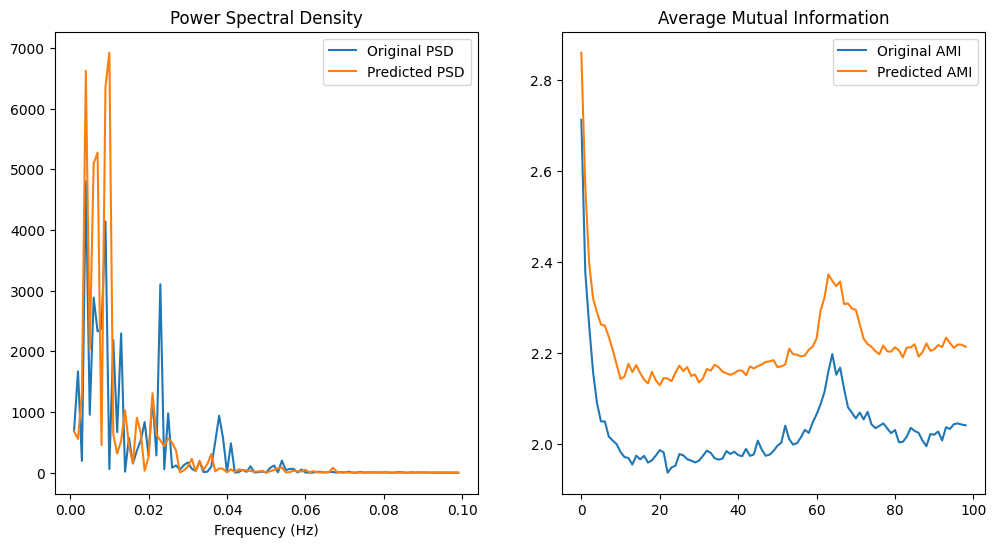

In [28]:
mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(X[8000:9000],X[9000:10000] ,plot = True)

In [29]:
mse

np.float64(0.19294496281893617)

In [25]:
mse_psd

np.float64(3400475.0424255747)

In [23]:
le_o

np.float64(0.0082127946537744)

In [24]:
le_p

np.float64(0.010188044720148061)